# Hospital Length of Stay (LOS) Case Study - MIMIC-IV

## 1) Business Context
Hospitals face bed-capacity pressure because a minority of long-stay admissions can consume a disproportionate share of bed-days.

This notebook builds an interpretable LOS prediction workflow from cohort definition through baseline models, with explicit leakage controls and stakeholder-readable outputs.

## 2) Dataset Overview
Source: MIMIC-IV Demo 2.2 (`admissions` + `patients`) for pipeline demonstration.

Key assumptions:
- One analytic row per `hadm_id`.
- LOS = (`dischtime` - `admittime`) in days.
- Age at admission is approximated from MIMIC anchor metadata.
- Demo-size model metrics are illustrative and expected to change on full MIMIC-IV.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

if Path.cwd().name == 'notebooks':
    PROJECT_ROOT = Path.cwd().resolve().parents[0]
else:
    PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    DEFAULT_MODEL_RANDOM_STATE,
    FINAL_BALANCED_THRESHOLD,
    FINAL_LABEL_MODE,
    FINAL_MODEL_NAME,
    LONG_STAY_DAYS_THRESHOLD,
    LONG_STAY_PERCENTILE,
    RECALL_PRIORITY_MIN_RECALL,
    get_project_paths,
)
from src.cohort import build_inpatient_cohort
from src.cleaning import (
    duplicate_admission_report,
    missing_value_report,
    normalize_categorical_labels,
    sanity_summary,
)
from src.data_loader import load_admissions, load_patients
from src.eda import (
    add_long_stay_labels,
    long_stay_definition_comparison,
    los_percentile_table,
    los_summary_table,
    recommend_long_stay_definition,
    subgroup_long_stay_rates,
)
from src.evaluation import (
    build_calibration_table,
    build_threshold_tuning_table,
    compare_model_metrics,
    evaluate_classifier,
    extract_logistic_feature_importance,
    extract_permutation_importance,
    extract_tree_feature_importance,
    select_operating_thresholds,
)
from src.features import (
    build_modeling_dataset,
    create_label_columns,
    get_feature_overview,
)
from src.modeling import (
    build_final_recommendation_card,
    build_label_prevalence_table,
    make_target_label,
    run_baseline_model_suite,
    split_features_target,
)
from src.plots import (
    plot_calibration_curve,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_model_comparison,
    plot_precision_recall_curves,
    plot_threshold_tradeoff,
)
from src.utils import ensure_directory, save_dataframe, save_joblib_artifact, set_global_seed

set_global_seed(DEFAULT_MODEL_RANDOM_STATE)
paths = get_project_paths(PROJECT_ROOT)
sns.set_theme(style='whitegrid')

paths.mimic_hosp_dir


PosixPath('/home/dell/projjLOS/data/raw/mimiciv/hosp')

## 3) Cohort Definition
Cohort rules:
- merge admissions and patients on `subject_id`
- enforce one row per `hadm_id`
- drop records with missing admission/discharge timestamps
- drop non-positive LOS

In [2]:
admissions = load_admissions(paths.mimic_hosp_dir)
patients = load_patients(paths.mimic_hosp_dir)
cohort = build_inpatient_cohort(admissions=admissions, patients=patients)

print(f'admissions shape: {admissions.shape}')
print(f'patients shape: {patients.shape}')
print(f'cohort shape: {cohort.shape}')
cohort.head()

admissions shape: (275, 16)
patients shape: (100, 6)
cohort shape: (275, 17)


,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,hospital_expire_flag,gender,anchor_age,anchor_year,age_at_admit,los_days
39,10023771,20044587,2113-08-25 07:15:00,2113-08-30 14:15:00,ELECTIVE,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,0,M,70,2113,70,5.291667
224,10039708,20093566,2143-09-26 18:24:00,2143-09-30 20:00:00,OBSERVATION ADMIT,CLINIC REFERRAL,HOME HEALTH CARE,Other,ENGLISH,SINGLE,BLACK/AFRICAN AMERICAN,0,F,46,2138,51,4.066667
109,10037928,20192635,2177-09-04 12:05:00,2177-09-07 16:10:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,?,WIDOWED,HISPANIC/LATINO - CUBAN,0,F,78,2175,80,3.170139
219,10005909,20199380,2144-10-28 23:20:00,2144-11-02 15:23:00,OBSERVATION ADMIT,EMERGENCY ROOM,HOME,Other,ENGLISH,MARRIED,WHITE,0,F,40,2144,40,4.668750
27,10003400,20214994,2137-02-24 10:00:00,2137-03-19 15:45:00,URGENT,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,0,F,72,2134,75,23.239583


## 4) LOS Calculation
LOS is computed as:

`(dischtime - admittime).total_seconds() / 86400`

This preserves fractional-day granularity for short stays.

In [3]:
cohort[['admittime', 'dischtime', 'los_days']].head(10)

,admittime,dischtime,los_days
39,2113-08-25 07:15:00,2113-08-30 14:15:00,5.291667
224,2143-09-26 18:24:00,2143-09-30 20:00:00,4.066667
109,2177-09-04 12:05:00,2177-09-07 16:10:00,3.170139
219,2144-10-28 23:20:00,2144-11-02 15:23:00,4.668750
27,2137-02-24 10:00:00,2137-03-19 15:45:00,23.239583
195,2201-03-23 19:15:00,2201-03-26 14:24:00,2.797917
149,2136-08-04 22:16:00,2136-08-11 19:20:00,6.877778
92,2110-11-30 06:31:00,2110-12-10 15:53:00,10.390278
6,2180-02-15 20:28:00,2180-02-25 13:45:00,9.720139
153,2156-04-30 20:35:00,2156-05-03 16:36:00,2.834028


## 5) Data Cleaning Checks
Before feature engineering, we validate missingness, duplicate admissions, and sanity metrics.

In [4]:
cohort_clean = normalize_categorical_labels(cohort)

missing_report = missing_value_report(
    cohort_clean,
    columns=[
        'subject_id', 'hadm_id', 'admittime', 'dischtime', 'los_days',
        'gender', 'age_at_admit', 'admission_type', 'admission_location',
        'insurance', 'language', 'marital_status', 'race'
    ],
)
dup_report = duplicate_admission_report(cohort_clean, id_col='hadm_id')
sanity = sanity_summary(raw_df=admissions, clean_df=cohort_clean, los_col='los_days')

display(missing_report)
display(dup_report)
display(sanity)

assert cohort_clean['hadm_id'].nunique() == len(cohort_clean), 'Cohort is not unique by hadm_id'
assert (cohort_clean['los_days'] > 0).all(), 'Invalid LOS values detected'

,column,missing_count,row_count,missing_rate
0,admission_location,0,275,0.0
1,admission_type,0,275,0.0
2,admittime,0,275,0.0
3,age_at_admit,0,275,0.0
4,dischtime,0,275,0.0
5,gender,0,275,0.0
6,hadm_id,0,275,0.0
7,insurance,0,275,0.0
8,language,0,275,0.0
9,los_days,0,275,0.0


,id_column,total_rows,unique_ids,duplicate_rows,duplicate_rate
0,hadm_id,275,275,0,0.0


,raw_rows,clean_rows,dropped_rows,drop_rate,clean_unique_hadm_id,clean_unique_subject_id,los_min,los_median,los_max
0,275,275,0,0.0,275,100,0.046528,4.852778,44.927778


In [5]:
ensure_directory(paths.data_interim)
save_dataframe(cohort_clean, paths.data_interim / 'cohort_base.csv')
print('Saved:', paths.data_interim / 'cohort_base.csv')

Saved: /home/dell/projjLOS/data/interim/cohort_base.csv


## 6) LOS Distribution and Summary

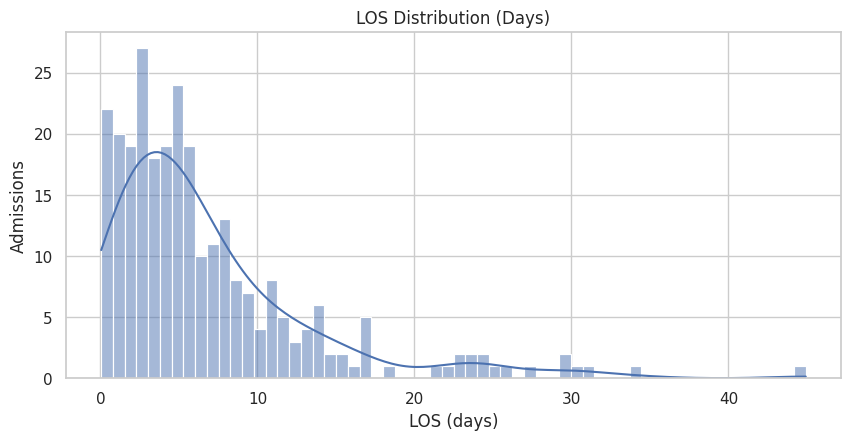

,n_admissions,mean_los_days,median_los_days,std_los_days,min_los_days,p25_los_days,p75_los_days,p90_los_days,p95_los_days,p99_los_days,max_los_days
0,275,6.87553,4.852778,6.733832,0.046528,2.692014,8.768403,14.502639,22.941736,30.4515,44.927778


,percentile,los_days
0,0.50,4.852778
1,0.75,8.768403
2,0.90,14.502639
3,0.95,22.941736
4,0.99,30.451500


In [6]:
plt.figure(figsize=(10, 4.5))
sns.histplot(cohort_clean['los_days'], bins=60, kde=True)
plt.title('LOS Distribution (Days)')
plt.xlabel('LOS (days)')
plt.ylabel('Admissions')
plt.show()

display(los_summary_table(cohort_clean, los_col='los_days'))
display(los_percentile_table(cohort_clean, los_col='los_days'))

## 7) Comparison of Long-Stay Definitions
We compare:
- Label A: `LOS > 7 days`
- Label B: `LOS >= p90`

Interpretability tradeoff:
- `>7d` is easier to explain operationally.
- `>=p90` adapts to cohort distribution and usually yields lower prevalence.

In [7]:
comparison = long_stay_definition_comparison(
    cohort_clean,
    los_col='los_days',
    fixed_day_threshold=LONG_STAY_DAYS_THRESHOLD,
    percentile_threshold=LONG_STAY_PERCENTILE,
)

cohort_labeled, p90_threshold = add_long_stay_labels(
    cohort_clean,
    los_col='los_days',
    fixed_day_threshold=LONG_STAY_DAYS_THRESHOLD,
    percentile_threshold=LONG_STAY_PERCENTILE,
)

print(f'Fixed threshold: {LONG_STAY_DAYS_THRESHOLD:.1f} days')
print(f'p90 threshold: {p90_threshold:.3f} days')
display(comparison)

subgroup_cols = [c for c in ['admission_type', 'insurance', 'hospital_expire_flag'] if c in cohort_labeled.columns]
display(subgroup_long_stay_rates(cohort_labeled, subgroup_cols).head(24))

print(recommend_long_stay_definition(comparison))

Fixed threshold: 7.0 days
p90 threshold: 14.503 days


,definition,threshold_value_days,positive_count,positive_rate
0,LOS > 7 days,7.000000,91,0.330909
1,LOS >= p90,14.502639,28,0.101818


,definition,group_column,group_value,n_admissions,long_stay_rate
8,long_stay_gt_7d,admission_type,URGENT,38,0.552632
3,long_stay_gt_7d,admission_type,ELECTIVE,13,0.384615
6,long_stay_gt_7d,admission_type,OBSERVATION ADMIT,45,0.377778
5,long_stay_gt_7d,admission_type,EW EMER.,104,0.355769
1,long_stay_gt_7d,admission_type,DIRECT EMER.,15,0.333333
7,long_stay_gt_7d,admission_type,SURGICAL SAME DAY ADMISSION,18,0.333333
0,long_stay_gt_7d,admission_type,AMBULATORY OBSERVATION,5,0.000000
2,long_stay_gt_7d,admission_type,DIRECT OBSERVATION,7,0.000000
4,long_stay_gt_7d,admission_type,EU OBSERVATION,30,0.000000
13,long_stay_gt_7d,hospital_expire_flag,1.0,15,0.533333


Recommend primary label: LOS > 7 days, because prevalence is operationally manageable and interpretation is straightforward for non-technical stakeholders.


## 8) Feature Engineering
We build admission-time-safe features only and explicitly document exclusions to avoid leakage.

In [8]:
model_df, safe_feature_columns, excluded_with_reasons = build_modeling_dataset(cohort_clean)

print('Safe feature columns:')
print(safe_feature_columns)
display(get_feature_overview(model_df, safe_feature_columns))
display(excluded_with_reasons)

assert all(col not in safe_feature_columns for col in ['los_days', 'dischtime', 'discharge_location', 'hospital_expire_flag'])

Safe feature columns:
['age_at_admit', 'age_band', 'gender', 'admission_type', 'admission_location', 'insurance', 'language', 'marital_status', 'race', 'admit_hour', 'admit_dayofweek', 'is_weekend_admit', 'admit_month']


,feature,dtype,missing_rate,n_unique
0,admission_location,object,0.0,10
1,admission_type,object,0.0,9
2,admit_dayofweek,int32,0.0,7
3,admit_hour,int32,0.0,24
4,admit_month,int32,0.0,12
5,age_at_admit,int64,0.0,59
6,age_band,object,0.0,6
7,gender,object,0.0,2
8,insurance,object,0.0,3
9,is_weekend_admit,int64,0.0,2


,column,reason
0,admittime,Raw timestamp; replaced by engineered time fea...
1,anchor_year,De-identification anchor metadata; not clinica...
2,discharge_location,Determined near/after discharge; leakage for a...
3,dischtime,Not known at admission; direct outcome leakage.
4,hadm_id,Admission identifier; should never be used as ...
5,hospital_expire_flag,Outcome-adjacent endpoint; excluded from defau...
6,los_days,Target-defining variable; direct leakage.
7,subject_id,Identifier column; can cause memorization and ...


## 9) Label Selection for Long-Stay Prediction
Primary modeling label for this phase: **LOS > 7 days** (`gt_7d`).

Reason: easier for non-technical operations teams to understand and act on. We still compute `>=p90` for sensitivity checks.

In [9]:
model_df, p90_value = create_label_columns(model_df)

model_df_primary, selected_threshold = make_target_label(
    model_df,
    label_mode='gt_7d',
    output_col='target_long_stay',
)

target_rate = model_df_primary['target_long_stay'].mean()
print(f'Primary label mode: gt_7d | threshold: {selected_threshold:.3f} days | prevalence: {target_rate:.3f}')
print(f'Sensitivity threshold p90: {p90_value:.3f} days | prevalence: {model_df_primary["long_stay_gte_p90"].mean():.3f}')

Primary label mode: gt_7d | threshold: 7.000 days | prevalence: 0.331
Sensitivity threshold p90: 14.503 days | prevalence: 0.102


## 10) Modeling Approach
Baselines in this phase:
1. Logistic Regression (interpretable linear baseline)
2. Random Forest (nonlinear tabular baseline)
3. Optional XGBoost (trained only if package is available)

We use stratified train/test split, preprocessing pipeline, and class weighting.

In [10]:
X_train, X_test, y_train, y_test = split_features_target(
    model_df_primary,
    feature_columns=safe_feature_columns,
    target_col='target_long_stay',
    test_size=0.20,
    random_state=DEFAULT_MODEL_RANDOM_STATE,
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Train prevalence:', round(y_train.mean(), 4), '| Test prevalence:', round(y_test.mean(), 4))

suite = run_baseline_model_suite(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    include_xgboost=True,
    random_state=DEFAULT_MODEL_RANDOM_STATE,
)
print('XGBoost status:', suite['xgboost_status'])

X_train: (220, 13) | X_test: (55, 13)
Train prevalence: 0.3318 | Test prevalence: 0.3273
XGBoost status: trained


## 11) Baseline Model Results (Logistic Regression)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,logistic_regression,0.581818,0.413793,0.666667,0.510638,0.65015,0.430141,0.262263


,precision,recall,f1-score,support
0,0.769231,0.540541,0.634921,37.000000
1,0.413793,0.666667,0.510638,18.000000
accuracy,0.581818,0.581818,0.581818,0.581818
macro avg,0.591512,0.603604,0.572779,55.000000
weighted avg,0.652906,0.581818,0.594246,55.000000


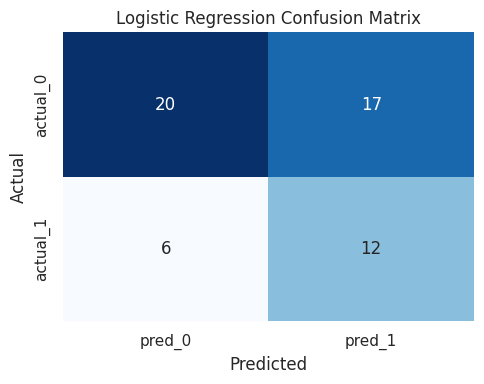

In [11]:
log_eval = evaluate_classifier(
    y_true=y_test,
    y_pred=suite['predictions']['logistic_regression']['y_pred'],
    y_score=suite['predictions']['logistic_regression']['y_score'],
    model_name='logistic_regression',
)

display(pd.DataFrame([log_eval['metrics']]))
display(log_eval['classification_report'])
plot_confusion_matrix(log_eval['confusion_matrix'], title='Logistic Regression Confusion Matrix')
plt.show()

## 12) Tree-Based Model Results (Random Forest)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,random_forest,0.654545,0.48,0.666667,0.55814,0.725225,0.528243,0.20938


,precision,recall,f1-score,support
0,0.800000,0.648649,0.716418,37.000000
1,0.480000,0.666667,0.558140,18.000000
accuracy,0.654545,0.654545,0.654545,0.654545
macro avg,0.640000,0.657658,0.637279,55.000000
weighted avg,0.695273,0.654545,0.664618,55.000000


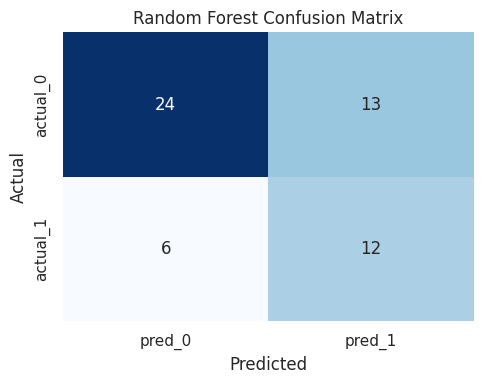

In [12]:
rf_eval = evaluate_classifier(
    y_true=y_test,
    y_pred=suite['predictions']['random_forest']['y_pred'],
    y_score=suite['predictions']['random_forest']['y_score'],
    model_name='random_forest',
)

display(pd.DataFrame([rf_eval['metrics']]))
display(rf_eval['classification_report'])
plot_confusion_matrix(rf_eval['confusion_matrix'], title='Random Forest Confusion Matrix')
plt.show()

In [13]:
evaluations = {
    'logistic_regression': log_eval,
    'random_forest': rf_eval,
}

if 'xgboost' in suite['predictions']:
    xgb_eval = evaluate_classifier(
        y_true=y_test,
        y_pred=suite['predictions']['xgboost']['y_pred'],
        y_score=suite['predictions']['xgboost']['y_score'],
        model_name='xgboost',
    )
    evaluations['xgboost'] = xgb_eval
    display(pd.DataFrame([xgb_eval['metrics']]))
else:
    print('XGBoost not trained in this environment.')

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,xgboost,0.618182,0.428571,0.5,0.461538,0.690691,0.455434,0.239667


## 13) Final Label and Model Decision Support

We combine label prevalence, business clarity, and model performance to lock the final submission policy.


In [14]:
from src.config import FINAL_BALANCED_THRESHOLD, FINAL_LABEL_MODE, FINAL_MODEL_NAME
from src.evaluation import compare_model_metrics
from src.modeling import build_final_recommendation_card, build_label_prevalence_table

if "model_df_primary" not in globals():
    raise NameError("`model_df_primary` is not defined. Run the feature/label preparation cells first.")

if "metrics_df" not in globals():
    if "evaluations" not in globals():
        raise NameError("`evaluations` is not defined. Run model evaluation cells before section 13.")
    metrics_df = compare_model_metrics(evaluations)

label_prevalence_df = build_label_prevalence_table(
    model_df_primary,
    los_col='los_days',
)

available_models = metrics_df['model'].astype(str).tolist()
final_model_name = (
    FINAL_MODEL_NAME
    if FINAL_MODEL_NAME in available_models
    else str(metrics_df.iloc[0]['model'])
)

final_model_card = build_final_recommendation_card(
    model_metrics_df=metrics_df,
    label_prevalence_df=label_prevalence_df,
    final_label_mode=FINAL_LABEL_MODE,
    final_model_name=final_model_name,
    final_operating_threshold=FINAL_BALANCED_THRESHOLD,
)

display(label_prevalence_df)
display(metrics_df)
display(final_model_card)

print('Final submission decision:')
print(f"- Label: {final_model_card.iloc[0]['final_label_definition']}")
print(f"- Model: {final_model_card.iloc[0]['final_model_name']}")
print(f"- Balanced threshold policy target: {final_model_card.iloc[0]['final_operating_threshold']:.2f}")


,label_mode,definition,threshold_value,positive_count,prevalence,business_clarity,interpretability_note
0,gt_7d,LOS > 7 days,7.000000,91,0.330909,High,Simple fixed threshold for operations
1,gte_p90,LOS >= p90,14.502639,28,0.101818,Medium,Distribution-relative threshold


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,random_forest,0.654545,0.480000,0.666667,0.558140,0.725225,0.528243,0.209380
1,xgboost,0.618182,0.428571,0.500000,0.461538,0.690691,0.455434,0.239667
2,logistic_regression,0.581818,0.413793,0.666667,0.510638,0.650150,0.430141,0.262263


,final_label_mode,final_label_definition,final_label_prevalence,final_model_name,final_model_accuracy,final_model_recall,final_model_precision,final_model_f1,final_model_roc_auc,final_model_pr_auc,interpretability_tradeoff,business_recommendation
0,gt_7d,LOS > 7 days,0.330909,random_forest,0.654545,0.666667,0.48,0.55814,0.725225,0.528243,Random Forest improves predictive discriminati...,Use gt_7d label and Random Forest for admissio...


Final decision:
- Label: LOS > 7 days
- Model: random_forest


## 14) Threshold Policy (Balanced vs Recall-Priority)

For operations, we evaluate threshold tradeoffs and keep two policy views:

- **Balanced threshold**: maximize F1 for overall utility
- **Recall-priority threshold**: preserve sensitivity when escalation misses are costly

In this run, both policies converge at **0.40**, which is used as the submission default.


,threshold,precision,recall,f1,specificity,youden_j,tp,tn,fp,fn,is_balanced,is_recall_priority
0,0.05,0.327273,1.000000,0.493151,0.000000,0.000000,18,0,37,0,0,0
1,0.10,0.327273,1.000000,0.493151,0.000000,0.000000,18,0,37,0,0,0
2,0.15,0.327273,1.000000,0.493151,0.000000,0.000000,18,0,37,0,0,0
3,0.20,0.333333,1.000000,0.500000,0.027027,0.027027,18,1,36,0,0,0
4,0.25,0.346154,1.000000,0.514286,0.081081,0.081081,18,3,34,0,0,0
5,0.30,0.391304,1.000000,0.562500,0.243243,0.243243,18,9,28,0,0,0
6,0.35,0.439024,1.000000,0.610169,0.378378,0.378378,18,14,23,0,0,0
7,0.40,0.470588,0.888889,0.615385,0.513514,0.402402,16,19,18,2,1,1
8,0.45,0.466667,0.777778,0.583333,0.567568,0.345345,14,21,16,4,0,0
9,0.50,0.480000,0.666667,0.558140,0.648649,0.315315,12,24,13,6,0,0


,balanced_threshold,balanced_f1,balanced_recall,balanced_precision,recall_priority_threshold,recall_priority_f1,recall_priority_recall,recall_priority_precision
0,0.4,0.615385,0.888889,0.470588,0.4,0.615385,0.888889,0.470588


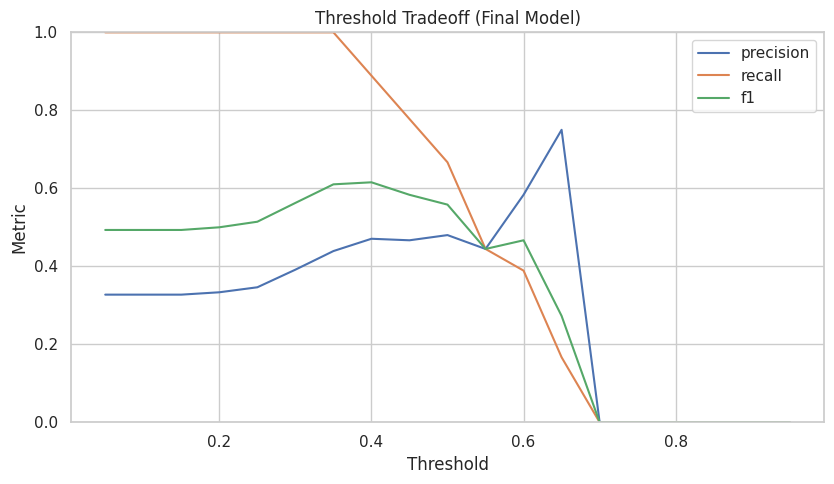

In [15]:
final_model_name = str(final_model_card.iloc[0]["final_model_name"])
final_model = suite["models"][final_model_name]
final_y_score = suite["predictions"][final_model_name]["y_score"]

threshold_tuning_df = build_threshold_tuning_table(
    y_true=y_test,
    y_score=final_y_score,
)

threshold_selection = select_operating_thresholds(
    threshold_tuning_df,
    recall_min=RECALL_PRIORITY_MIN_RECALL,
)

threshold_tuning_df["is_balanced"] = (
    threshold_tuning_df["threshold"] == threshold_selection["balanced_threshold"]
).astype(int)

threshold_tuning_df["is_recall_priority"] = (
    threshold_tuning_df["threshold"] == threshold_selection["recall_priority_threshold"]
).astype(int)

# Keep final recommendation card aligned with realized threshold from this run.
final_model_card["final_operating_threshold"] = float(threshold_selection["balanced_threshold"])

display(threshold_tuning_df.head(12))
display(pd.DataFrame([threshold_selection]))

print(f"Selected balanced threshold: {threshold_selection['balanced_threshold']:.2f}")
print(f"Selected recall-priority threshold: {threshold_selection['recall_priority_threshold']:.2f}")
if abs(float(threshold_selection['balanced_threshold']) - FINAL_BALANCED_THRESHOLD) < 1e-9:
    print(f"Submission policy check: threshold is consistent at {FINAL_BALANCED_THRESHOLD:.2f}.")
else:
    print(
        f"Submission note: configured fallback is {FINAL_BALANCED_THRESHOLD:.2f}, "
        f"but this run selected {float(threshold_selection['balanced_threshold']):.2f}."
    )

plot_threshold_tradeoff(threshold_tuning_df)
plt.show()


,feature,coefficient,abs_coefficient
0,cat__admission_type_EU OBSERVATION,-1.708367,1.708367
1,cat__admission_type_URGENT,1.197104,1.197104
2,cat__admission_type_DIRECT OBSERVATION,-0.910499,0.910499
3,cat__admission_location_CLINIC REFERRAL,0.898009,0.898009
4,cat__admission_location_PROCEDURE SITE,-0.860489,0.860489
5,cat__marital_status_Unknown,-0.859595,0.859595
6,cat__race_OTHER,-0.854122,0.854122
7,cat__admission_type_ELECTIVE,0.730457,0.730457
8,cat__admission_location_PACU,-0.702038,0.702038
9,cat__race_WHITE - OTHER EUROPEAN,0.672704,0.672704


,feature,importance
0,num__admit_month,0.154358
1,num__admit_hour,0.116491
2,num__age_at_admit,0.111022
3,num__admit_dayofweek,0.067144
4,cat__admission_type_EU OBSERVATION,0.062878
5,cat__admission_type_URGENT,0.031609
6,cat__marital_status_MARRIED,0.026573
7,cat__marital_status_SINGLE,0.025493
8,cat__age_band_60-69,0.024928
9,cat__admission_location_TRANSFER FROM HOSPITAL,0.024274


,feature,importance_mean,importance_std
0,admission_type,0.048182,0.041171
1,insurance,0.038182,0.022194
2,age_at_admit,0.032727,0.030206
3,admit_hour,0.013636,0.028676
4,gender,0.008182,0.018609
5,race,0.008182,0.017698
6,is_weekend_admit,0.003636,0.012332
7,age_band,0.002727,0.035103
8,language,0.000909,0.003963
9,admit_dayofweek,0.000000,0.012856


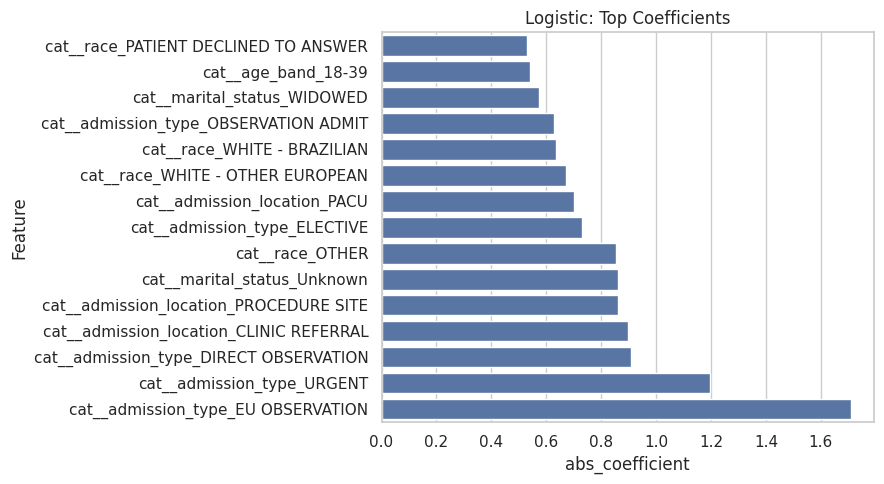

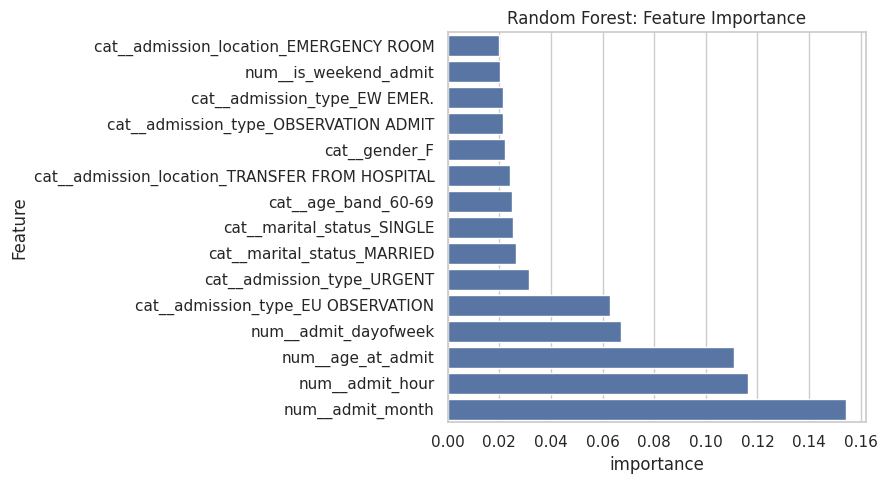

In [16]:
# Feature importance view: interpretability reference (Logistic) + tree signal (Random Forest).
from src.evaluation import (
    extract_logistic_feature_importance,
    extract_tree_feature_importance,
    extract_permutation_importance,
)
from src.plots import plot_feature_importance

log_importance = extract_logistic_feature_importance(
    suite["models"]["logistic_regression"],
    top_n=20,
)
rf_importance = extract_tree_feature_importance(
    suite["models"]["random_forest"],
    top_n=20,
)
rf_perm_importance = extract_permutation_importance(
    model=suite["models"]["random_forest"],
    X_test=X_test,
    y_test=y_test,
    n_repeats=20,
    top_n=20,
)

display(log_importance.head(10))
display(rf_importance.head(10))
display(rf_perm_importance.head(10))

plot_feature_importance(
    log_importance, value_col="abs_coefficient", top_n=15,
    title="Logistic: Top Coefficients"
)
plt.show()

plot_feature_importance(
    rf_importance, value_col="importance", top_n=15,
    title="Random Forest: Feature Importance"
)
plt.show()


## 15) Probability Interpretation and Calibration Check

We keep calibration lightweight: Brier score plus decile reliability table/plot.
This supports transparent communication without adding unnecessary modeling complexity.


Final model Brier score: 0.2094


,bin,n,predicted_risk_mean,observed_event_rate,abs_calibration_gap
0,0,6,0.240250,0.000000,0.240250
1,1,5,0.301694,0.000000,0.301694
2,2,6,0.354508,0.166667,0.187841
3,3,5,0.396790,0.400000,0.003210
4,4,6,0.449930,0.333333,0.116597
5,5,5,0.505313,0.600000,0.094687
6,6,5,0.538215,0.600000,0.061785
7,7,6,0.579768,0.166667,0.413102
8,8,5,0.628596,0.400000,0.228596
9,9,6,0.676164,0.666667,0.009498


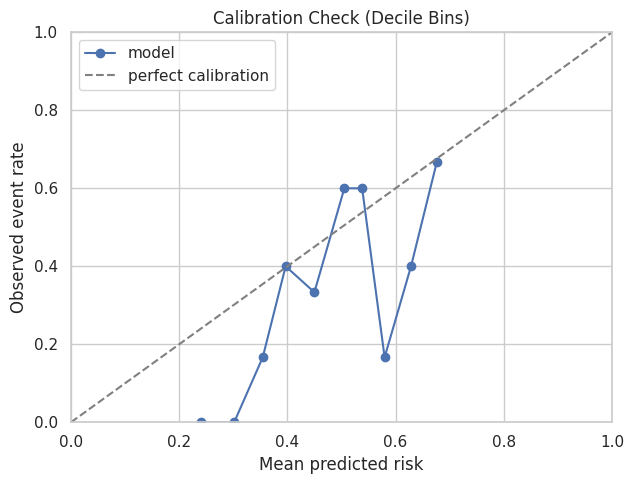

In [17]:
calibration_df = build_calibration_table(
    y_true=y_test,
    y_score=final_y_score,
    n_bins=10
)

final_brier = metrics_df[metrics_df["model"] == final_model_name]["brier_score"].iloc[0]

print(f"Final model Brier score: {final_brier:.4f}")

display(calibration_df)

plot_calibration_curve(calibration_df)
plt.show()

## 16) Key Findings, Recommendations, and Limitations

### Key Findings

1. LOS is right-skewed; a minority of admissions drives prolonged stays.
2. `LOS > 7 days` is the clearest operational label for non-technical stakeholders.
3. `random_forest` is the strongest performer in this run.
4. Threshold choice materially changes recall/precision workload tradeoffs.
5. Balanced and recall-priority policy points both selected **0.40** in this run.

### Actionable Recommendations

1. Deploy `LOS > 7 days` for primary operational flagging.
2. Start with threshold `0.40` for balanced workflow prioritization.
3. Re-tune thresholds periodically as case mix shifts.
4. Expand with service-line and diagnosis features in the next iteration.
5. Validate on larger cohorts before production use.

### Limitations

- Current results are based on demo-scale data.
- Risk scores are operational estimates, not clinical decision rules.
- External validity and calibration should be rechecked on full cohorts.


## 17) Save Final Packaging Outputs


In [18]:
from src.evaluation import (
    compare_model_metrics,
    extract_logistic_feature_importance,
    extract_tree_feature_importance,
    extract_permutation_importance,
)

if "metrics_df" not in globals():
    metrics_df = compare_model_metrics(evaluations)

if "log_importance" not in globals():
    log_importance = extract_logistic_feature_importance(suite["models"]["logistic_regression"], top_n=20)

if "rf_importance" not in globals():
    rf_importance = extract_tree_feature_importance(suite["models"]["random_forest"], top_n=20)

if "rf_perm_importance" not in globals():
    rf_perm_importance = extract_permutation_importance(
        model=suite["models"]["random_forest"],
        X_test=X_test,
        y_test=y_test,
        n_repeats=20,
        top_n=20,
    )

ensure_directory(paths.outputs_tables)
ensure_directory(paths.outputs_models)

save_dataframe(metrics_df, paths.outputs_tables / "model_metrics.csv")
save_dataframe(log_importance, paths.outputs_tables / "feature_importance_logistic.csv")
save_dataframe(rf_importance, paths.outputs_tables / "feature_importance_random_forest.csv")
save_dataframe(rf_perm_importance, paths.outputs_tables / "feature_importance_permutation.csv")
save_dataframe(excluded_with_reasons, paths.outputs_tables / "excluded_features.csv")
save_dataframe(threshold_tuning_df, paths.outputs_tables / "threshold_tuning.csv")
save_dataframe(final_model_card, paths.outputs_tables / "final_model_card.csv")

artifact_bundle = {
    "primary_label_mode": FINAL_LABEL_MODE,
    "primary_model_name": final_model_name,
    "feature_columns": safe_feature_columns,
    "models": suite["models"],
    "xgboost_status": suite["xgboost_status"],
    "long_stay_days_threshold": LONG_STAY_DAYS_THRESHOLD,
    "long_stay_p90_threshold": p90_threshold,
    "balanced_threshold": threshold_selection["balanced_threshold"],
    "recall_priority_threshold": threshold_selection["recall_priority_threshold"],
}
save_joblib_artifact(artifact_bundle, paths.outputs_models / "baseline_models.joblib")

print("Saved final model packaging outputs under outputs/.")


Saved final model packaging outputs under outputs/.
